# Article 1 — complete scientific analysis

**Server-side one-shot federated knowledge distillation with class-wise teacher expertise**

This notebook is the analytical source of truth for Article 1. It audits the completed corpus, reconstructs the experimental design, answers the research questions, exports paper-ready figures and tables, and classifies the claims supported by the data. It does not train models and never modifies raw experimental artifacts.

Scope: fully labeled in-domain public proxy, server-side expertise known from client holdout, ten clients, and local test used only to audit generalization. Label scarcity and expertise estimation belong to Article 2, not this notebook.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def find_repo(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / 'experiments' / 'article_1').is_dir():
            return path
    raise FileNotFoundError('Repository root not found')

REPO = find_repo()
RAW = REPO / 'OUTPUTS' / 'experiments' / 'article_1' / 'protocol_v1'
ANALYSIS = REPO / 'OUTPUTS' / 'experiments' / 'article_1' / 'paper_analysis'
FIGURES, TABLES = ANALYSIS / 'figures', ANALYSIS / 'tables'
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

DATASETS = ['mnist', 'fmnist', 'cifar']
DATASET_LABEL = {'mnist': 'MNIST', 'fmnist': 'Fashion-MNIST', 'cifar': 'CIFAR-10'}
REGIMES = ['iid', 'alpha1p0', 'alpha0p5', 'alpha0p1', 'multi', 'single']
REGIME_LABEL = {'iid': 'IID', 'alpha1p0': r'$\alpha=1.0$', 'alpha0p5': r'$\alpha=0.5$',
                'alpha0p1': r'$\alpha=0.1$', 'multi': 'multi', 'single': 'single'}
SEEDS = [42, 43, 44]
SIZES = [100, 250, 500, 1000, 2500, 5000, 10000]
CANONICAL = {'mnist': .9, 'fmnist': .8, 'cifar': .7}
CENTRAL = ['feddf', 'support_only', 'expert_full', 'expert_v2']
MECHANISM_CONTROL = ['expert_full', 'expert_v2', 'expert_full_entropy_matched']
CURVE = ['feddf', 'expert_v2', 'oracle_v2', 'supervised_matched', 'supervised_standard']
LABEL = {'feddf': 'FedDF', 'support_only': 'Support-only',
         'expert_full': 'EXPERT-full (v1)', 'expert_v2': 'EXPERT-support (v2)',
         'expert_full_entropy_matched': 'EXPERT-full, entropy-matched',
         'oracle_full': 'ORACLE-full', 'oracle_v2': 'ORACLE-class-only',
         'supervised_matched': 'Supervised matched',
         'supervised_standard': 'Supervised standard'}
COLOR = {'feddf': '#4C78A8', 'support_only': '#F58518', 'expert_full': '#54A24B',
         'expert_v2': '#E45756', 'expert_full_entropy_matched': '#8C6D31',
         'oracle_full': '#72B7B2', 'oracle_v2': '#B279A2',
         'supervised_matched': '#9D755D', 'supervised_standard': '#111111'}
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 125, 'savefig.dpi': 300, 'font.size': 9,
                     'axes.spines.top': False, 'axes.spines.right': False})

def save_figure(fig, stem):
    fig.savefig(FIGURES / f'{stem}.png', bbox_inches='tight')
    fig.savefig(FIGURES / f'{stem}.pdf', bbox_inches='tight')

def save_table(frame, stem):
    frame.to_csv(TABLES / f'{stem}.csv')
    return frame

def canonical(frame):
    expected = frame.dataset.map(CANONICAL).astype(float)
    return frame[np.isclose(frame.threshold.astype(float), expected)].copy()

target_rows = []
for path in RAW.glob('runs/**/target_metrics*.json'):
    payload = json.loads(path.read_text())
    target_rows.extend({**row, 'artifact': str(path.relative_to(REPO))}
                       for row in payload['methods'])
student_rows = [{**json.loads(path.read_text()), 'artifact': str(path.relative_to(REPO))}
                for path in RAW.glob('runs/**/students/*/metrics.json')]
source_rows = [json.loads(path.read_text()) for path in RAW.glob('sources/**/source.json')]
oracle_rows = []
for path in RAW.glob('runs/**/oracle_sanity.json'):
    rel = path.relative_to(RAW / 'runs').parts
    oracle_rows.append({**json.loads(path.read_text()), 'dataset': rel[0],
                        'seed': int(rel[1].split('_')[1]), 'regime': rel[2],
                        'proxy_size': int(rel[4].split('_')[1])})
targets = pd.DataFrame(target_rows)
students = pd.DataFrame(student_rows)
sources = pd.DataFrame(source_rows)
oracle_sanity = pd.DataFrame(oracle_rows)
execution_audit = json.loads((RAW / 'summary' / 'execution_audit.json').read_text())
assert execution_audit['status'] == 'verified'
print(f'Authoritative root: {RAW.relative_to(REPO)}')
print(f'Exports: {ANALYSIS.relative_to(REPO)}')

Authoritative root: OUTPUTS/experiments/article_1/protocol_v1
Exports: OUTPUTS/experiments/article_1/paper_analysis


## 1. Corpus audit and experimental scope

**Question.** Is the completed corpus internally consistent and sufficient for the planned paired analyses?

The authoritative corpus is `protocol_v1`: teacher sources were rebuilt from retained checkpoints, while masks, targets and students were regenerated in the clean Article 1 tree. Historical Study I directories are no longer present and are therefore not mixed into the paper analysis. FedDF is recomputed inside `protocol_v1` using the same teachers, proxy subsets and student recipe as the expertise methods. Teacher generation is accepted as correct, as specified for this analysis.

In [2]:
target_key = ['dataset', 'seed', 'regime', 'threshold', 'proxy_size', 'method']
student_key = target_key
central_students = canonical(students.query('proxy_size == 10000 and method in @CENTRAL'))
curve_students = canonical(students.query('seed == 42 and method in @CURVE'))
audit_table = pd.DataFrame([
    ['Teacher sources', len(sources), 54],
    ['Target conditions', execution_audit['target_conditions_checked'], 198],
    ['Student trainings', execution_audit['student_trainings_checked'], 864],
    ['Central method rows', len(central_students), 216],
    ['Proxy-curve rows', len(curve_students), 630],
    ['Duplicated target keys', targets.duplicated(target_key).sum(), 0],
    ['Duplicated student keys', students.duplicated(student_key).sum(), 0],
], columns=['Audit item', 'Observed', 'Expected'])
display(audit_table)

leakage = pd.Series(execution_audit['checks'], name='Verified').rename_axis('Invariant').to_frame()
coverage = pd.DataFrame(execution_audit['planned_analysis_coverage']).T
display(Markdown('**Data-use invariants**'))
display(leakage)
display(Markdown('**Planned-analysis coverage**'))
display(coverage)

paired_fields = ['student_init_sha256', 'train_order_sha256', 'total_updates', 'paired_run_id']
pair_violations = 0
for _, block in central_students.groupby(['dataset', 'seed', 'regime']):
    for field in paired_fields:
        pair_violations += block[field].nunique() != 1
issues = []
if pair_violations: issues.append(f'{pair_violations} CRN/pairing violations')
if set(targets.dataset) != set(DATASETS): issues.append('dataset naming mismatch')
if set(targets.regime) != set(REGIMES): issues.append('regime naming mismatch')
if set(students.seed) != set(SEEDS): issues.append('seed coverage mismatch')
if (REPO / 'OUTPUTS' / 'experiments' / 'study_i').exists():
    issues.append('legacy Study I exists but is intentionally excluded')
display(Markdown('**Interpretation-affecting inconsistencies:** ' +
                 ('; '.join(issues) if issues else 'none in the authoritative corpus.')))
save_table(audit_table, 'table_audit')

,Audit item,Observed,Expected
0,Teacher sources,54,54
1,Target conditions,198,198
2,Student trainings,864,864
3,Central method rows,216,216
4,Proxy-curve rows,630,630
5,Duplicated target keys,0,0
6,Duplicated student keys,0,0


**Data-use invariants**

,Verified
Invariant,
client_train_holdout_test_and_proxy_disjoint,True
every_proxy_subset_is_a_nested_source_prefix,True
every_saved_mask_recomputed_from_holdout_only,True
every_student_target_hash_matches_saved_target,True
expert_v1_v2_common_random_numbers,True
oracle_v2_onehot_except_no_correct_fallback,True
student_optimization_never_reads_test_loader,True
teacher_generation_assumed_correct,True


**Planned-analysis coverage**

,complete,expected,observed,paired_cells,expected_target_conditions,observed_target_conditions
expert_v1_vs_v2,True,216,216,54,NaN,NaN
kd_proxy_sample_efficiency,True,630,630,NaN,NaN,NaN
oracle_v2_onehot,True,NaN,NaN,NaN,198,198
supervised_proxy_curve,True,252,252,NaN,NaN,NaN


**Interpretation-affecting inconsistencies:** none in the authoritative corpus.

,Audit item,Observed,Expected
0,Teacher sources,54,54
1,Target conditions,198,198
2,Student trainings,864,864
3,Central method rows,216,216
4,Proxy-curve rows,630,630
5,Duplicated target keys,0,0
6,Duplicated student keys,0,0


### Final protocol

For client $k$, the private data roles are

$$D_k^{train},\qquad D_k^{holdout},\qquad D_k^{test}.$$

Only $D_k^{train}$ adjusts teacher parameters. Holdout selects the teacher checkpoint and estimates class-wise expertise $M_{k,c}=1[Acc_{k,c}^{holdout}\geq\tau]$. Local test never changes $M$ and is used only to audit whether holdout-defined expertise generalizes. The public proxy is fully labeled and disjoint from all client splits; using its labels for EXPERT routing, ORACLE and supervised controls is part of the Article 1 setting, not test leakage.

In [3]:
architectures = (sources.groupby('dataset').agg(Teacher_architecture=('teacher_architecture', 'first'),
                                                 Clients=('num_teachers', 'first'),
                                                 Classes=('num_classes', 'first'))
                 .reindex(DATASETS))
architectures['Student_architecture'] = architectures['Teacher_architecture']
architectures['Expertise_threshold'] = pd.Series(CANONICAL)
architectures['Seeds'] = '42/43/44 (central); 42 (secondary)'
display(save_table(architectures, 'table_experimental_setup'))

method_table = pd.DataFrame([
    ['FedDF', 'all', 'full', False, False, 'KD baseline'],
    ['Support-only', 'all', 'expertise support', True, False, 'support without routing'],
    ['EXPERT-full (v1)', r'$M_{k,y}=1$', 'full', True, True, 'historical EXPERT'],
    ['EXPERT-support (v2)', r'$M_{k,y}=1$', 'expertise support', True, True, 'support intervention'],
    ['ORACLE-full', 'teacher predicts y', 'full', True, True, 'soft correct-teacher control'],
    ['ORACLE-class-only', 'teacher predicts y', 'true class only', True, True, 'hard-label control + fallback'],
    ['Supervised matched', 'none', 'one-hot y', True, False, 'same KD optimization budget'],
    ['Supervised standard', 'none', 'one-hot y', True, False, '100-epoch supervised recipe'],
], columns=['Method', 'Teachers contributing', 'Allowed output', 'Uses proxy labels',
            'Uses expertise/teacher state', 'Scientific role']).set_index('Method')
display(save_table(method_table, 'table_method_information'))

recipe = (students.groupby(['training_recipe', 'loss'])
          .agg(Epochs=('epochs', lambda x: sorted(set(x))),
               Optimizer=('optimizer', 'first'), Scheduler=('scheduler', 'first'),
               Temperature=('temperature', 'first')).reset_index())
display(recipe)
display(Markdown('All KD/matched methods use $T=8$, AdamW, 30 epochs and common random numbers within each paired cell. Standard supervised uses cross-entropy, augmentation, cosine scheduling and 100 epochs.'))

,Teacher_architecture,Clients,Classes,Student_architecture,Expertise_threshold,Seeds
dataset,,,,,,
mnist,mnist_net,10,10,mnist_net,0.9,42/43/44 (central); 42 (secondary)
fmnist,mnist_net,10,10,mnist_net,0.8,42/43/44 (central); 42 (secondary)
cifar,resnet9,10,10,resnet9,0.7,42/43/44 (central); 42 (secondary)


,Teachers contributing,Allowed output,Uses proxy labels,Uses expertise/teacher state,Scientific role
Method,,,,,
FedDF,all,full,False,False,KD baseline
Support-only,all,expertise support,True,False,support without routing
EXPERT-full (v1),"$M_{k,y}=1$",full,True,True,historical EXPERT
EXPERT-support (v2),"$M_{k,y}=1$",expertise support,True,True,support intervention
ORACLE-full,teacher predicts y,full,True,True,soft correct-teacher control
ORACLE-class-only,teacher predicts y,true class only,True,True,hard-label control + fallback
Supervised matched,none,one-hot y,True,False,same KD optimization budget
Supervised standard,none,one-hot y,True,False,100-epoch supervised recipe


,training_recipe,loss,Epochs,Optimizer,Scheduler,Temperature
0,paired_kd,kd_kl,[30],adamw,none,8.0
1,supervised_standard,cross_entropy,[100],adamw,cosine_per_update,NaN


All KD/matched methods use $T=8$, AdamW, 30 epochs and common random numbers within each paired cell. Standard supervised uses cross-entropy, augmentation, cosine scheduling and 100 epochs.

## 2. What changes from FULL to SUPPORT?

For temperature-scaled teacher distribution $p_k^{(T)}(x)$, EXPERT-full selects teachers with $M_{k,y}=1$ and averages their complete vectors. EXPERT-support selects **the same teachers**, but replaces each vector by

$$\tilde p_{k,c}(x)=\frac{p_{k,c}^{(T)}(x)M_{k,c}}{\sum_j p_{k,j}^{(T)}(x)M_{k,j}}.$$

Thus FULL→SUPPORT changes what selected teachers may say, not who is selected. Support-only applies the same restriction without routing and isolates support from selection. ORACLE-class-only is different: it selects teachers that predict the current true label and then emits the true one-hot target whenever at least one is correct.

In [4]:
example = pd.DataFrame({'class': ['A', 'B', 'C'], 'teacher p(T)': [.55, .30, .15],
                        'expertise M': [1, 0, 1]})
example['supported and normalized'] = (example['teacher p(T)'] * example['expertise M'])
example['supported and normalized'] /= example['supported and normalized'].sum()
display(example.set_index('class'))
display(Markdown('The teacher still assigns 0.30 probability outside expertise; support removes it and renormalizes $[0.55,0,0.15]$ to $[0.786,0,0.214]$.'))

,teacher p(T),expertise M,supported and normalized
class,,,
A,0.55,1,0.785714
B,0.30,0,0.000000
C,0.15,1,0.214286


The teacher still assigns 0.30 probability outside expertise; support removes it and renormalizes $[0.55,0,0.15]$ to $[0.786,0,0.214]$.

## 3. Diagnostic — does out-of-expertise mass exist?

**Research question.** When EXPERT routes a sample to a teacher competent in its true class, how much probability remains on classes outside that teacher's expertise? Teacher-level removal averages selected teacher events; target-level removal averages the resulting per-sample mass. Seed variability is shown explicitly.

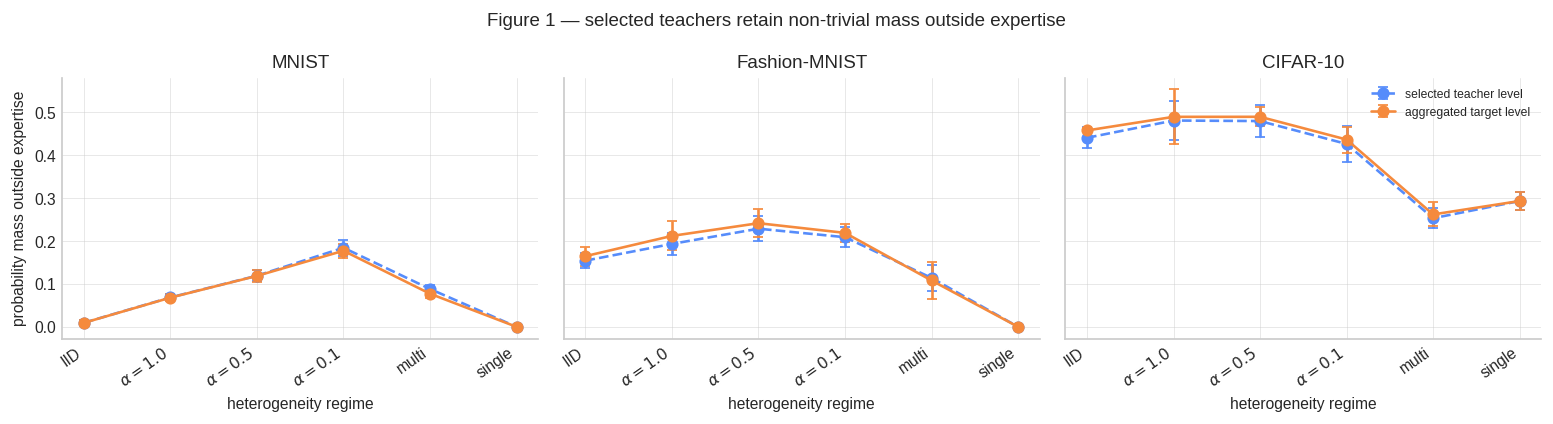

,teacher_mass_removed,mass_removed
dataset,,
cifar,0.395,0.404
fmnist,0.150,0.157
mnist,0.078,0.075


**Result.** The unwanted mass is substantial but strongly dataset-dependent. It is largest on CIFAR-10 and smallest on MNIST. It does not rise monotonically along the entire regime sequence: `single` is a limiting case, and CIFAR-10 is already high in IID/Dirichlet conditions. The mechanism exists; the stronger claim that it simply increases with specialization is not supported.

In [5]:
central_targets = canonical(targets.query('proxy_size == 10000 and method in @CENTRAL'))
mechanism = central_targets.query("method == 'expert_v2'").copy()
mechanism['mean_support_classes'] = mechanism.mask_support_per_teacher.map(np.mean)
mechanism['min_class_coverage'] = mechanism.mask_coverage_per_class.map(np.min)
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4), sharey=True)
for ax, dataset in zip(axes, DATASETS):
    block = mechanism.query('dataset == @dataset')
    for metric, label, style in [('teacher_mass_removed', 'selected teacher level', '--'),
                                  ('mass_removed', 'aggregated target level', '-')]:
        stats = block.groupby('regime')[metric].agg(['mean', 'std']).reindex(REGIMES)
        ax.errorbar(range(len(REGIMES)), stats['mean'], yerr=stats['std'], marker='o',
                    capsize=3, linestyle=style, label=label)
    ax.set_title(DATASET_LABEL[dataset]); ax.set_xticks(range(len(REGIMES)))
    ax.set_xticklabels([REGIME_LABEL[x] for x in REGIMES], rotation=35, ha='right')
    ax.set_xlabel('heterogeneity regime')
axes[0].set_ylabel('probability mass outside expertise')
axes[-1].legend(fontsize=7, loc='upper right')
fig.suptitle('Figure 1 — selected teachers retain non-trivial mass outside expertise')
fig.tight_layout(); save_figure(fig, 'fig1_out_of_expertise_mass'); plt.show()

mechanism_summary = (mechanism.groupby(['dataset', 'regime'])
    [['teacher_mass_removed', 'mass_removed', 'mask_density', 'mean_support_classes',
      'mean_selected_teachers', 'fallback_rate']].agg(['mean', 'std']))
save_table(mechanism_summary, 'table_mechanism_summary')
dataset_mass = mechanism.groupby('dataset')[['teacher_mass_removed', 'mass_removed']].mean()
display(dataset_mass.round(3))
display(Markdown('**Result.** The unwanted mass is substantial but strongly dataset-dependent. It is largest on CIFAR-10 and smallest on MNIST. It does not rise monotonically along the entire regime sequence: `single` is a limiting case, and CIFAR-10 is already high in IID/Dirichlet conditions. The mechanism exists; the stronger claim that it simply increases with specialization is not supported.'))

## 4–6. Factorial comparison, target quality, and trained student

The $2\times2$ comparison separates teacher selection from output restriction: FedDF→EXPERT-full measures routing; FedDF→Support-only measures support without routing; EXPERT-full→EXPERT-support is the clean support intervention; FedDF→EXPERT-support is the total effect. Target quality is inspected before student performance.

Δ target accuracy        Δ target NLL        Δ Brier         \
                     mean    std         mean    std    mean    std   
dataset                                                               
cifar               0.047  0.043       -0.528  0.170  -0.217  0.085   
fmnist              0.015  0.015       -0.177  0.105  -0.081  0.052   
mnist               0.002  0.003       -0.078  0.068  -0.038  0.034   

        Δ true-class probability        Δ entropy         
                            mean    std      mean    std  
dataset                                                   
cifar                      0.225  0.060    -0.769  0.264  
fmnist                     0.073  0.042    -0.222  0.149  
mnist                      0.040  0.035    -0.129  0.131

**Target result.** NLL improves in all 54 paired cells: **True**. True-class probability increases in all cells: **True**. Mean ΔNLL = **-0.261**. Support reliably sharpens the target.

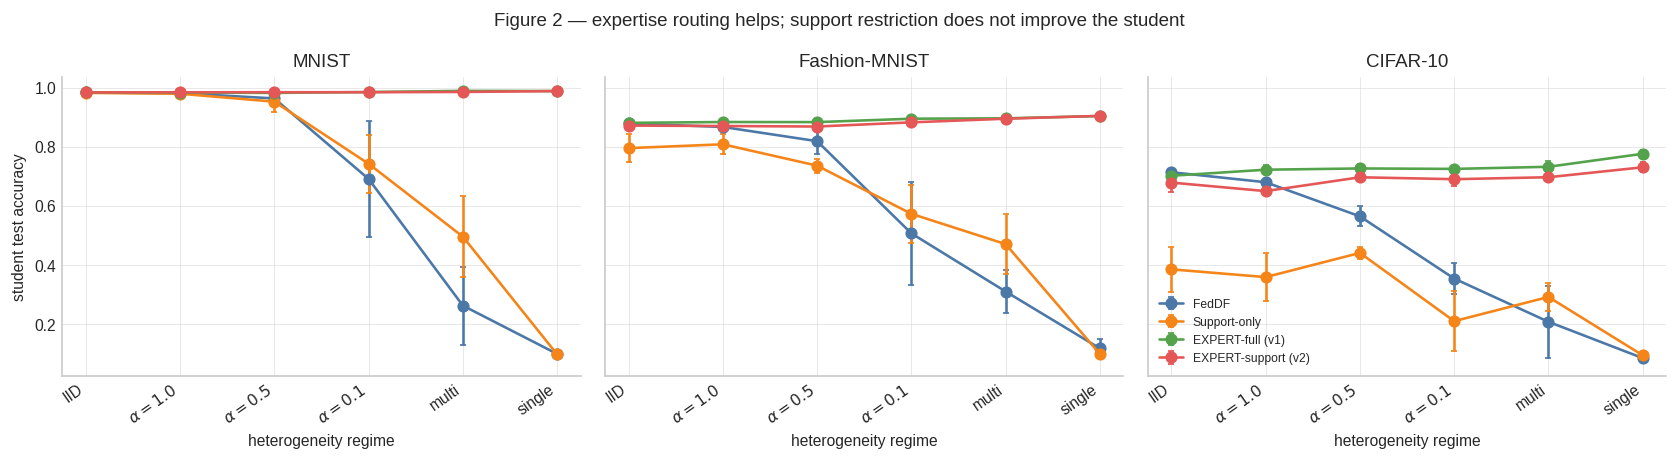

Mean      SD  Wins >0.1pp  \
Comparison                      Dataset                                
Selection: EXPERT-full − FedDF  mnist    0.3213  0.3802           15   
                                fmnist   0.3068  0.3183           17   
                                cifar    0.2961  0.2677           15   
                                all      0.3081  0.3193           47   
Support only − FedDF            mnist    0.0447  0.1048            7   
                                fmnist  -0.0029  0.1007            5   
                                cifar   -0.1371  0.1689            4   
                                all     -0.0317  0.1482           16   
Support intervention: v2 − full mnist   -0.0002  0.0022            5   
                                fmnist  -0.0085  0.0099            3   
                                cifar   -0.0401  0.0270            1   
                                all     -0.0163  0.0238            9   
Total: v2 − FedDF               mnist    0.3211  0.3790           16   
                                fmnist   0.2983  0.3235           12   
                                cifar    0.2560  0.2678           12   
                                all      0.2918  0.3216           40   

                                         Near-zero  Losses <-0.1pp   N  
Comparison                      Dataset                                 
Selection: EXPERT-full − FedDF  mnist            3               0  18  
                                fmnist           1               0  18  
                                cifar            0               3  18  
                                all              4               3  54  
Support only − FedDF            mnist            2               9  18  
                                fmnist           2              11  18  
                                cifar            0              14  18  
                                all              4              34  54  
Support intervention: v2 − full mnist            8               5  18  
                                fmnist           3              12  18  
                                cifar            0              17  18  
                                all             11              34  54  
Total: v2 − FedDF               mnist            2               0  18  
                                fmnist           2               4  18  
                                cifar            0               6  18  
                                all              4              10  54

**Student result.** Selection is valuable (mean EXPERT-full−FedDF **+0.308**), but support restriction reduces mean accuracy by **-0.016**. It wins in 9 cells, is near-zero in 11, and loses in 34 of 54. This is outcome B: the target improves, but the student generally does not.

In [6]:
INDEX = ['dataset', 'seed', 'regime']
central_students = canonical(students.query('proxy_size == 10000 and method in @CENTRAL'))
student_pivot = central_students.pivot(index=INDEX, columns='method', values='student_test_accuracy')
target_pivots = {metric: central_targets.pivot(index=INDEX, columns='method', values=metric)
                 for metric in ['target_accuracy', 'target_nll', 'target_brier',
                                'target_true_probability', 'target_entropy']}
target_delta = pd.DataFrame({
    'Δ target accuracy': target_pivots['target_accuracy'].expert_v2 - target_pivots['target_accuracy'].expert_full,
    'Δ target NLL': target_pivots['target_nll'].expert_v2 - target_pivots['target_nll'].expert_full,
    'Δ Brier': target_pivots['target_brier'].expert_v2 - target_pivots['target_brier'].expert_full,
    'Δ true-class probability': target_pivots['target_true_probability'].expert_v2 - target_pivots['target_true_probability'].expert_full,
    'Δ entropy': target_pivots['target_entropy'].expert_v2 - target_pivots['target_entropy'].expert_full,
})
target_effect = target_delta.groupby(level='dataset').agg(['mean', 'std'])
display(save_table(target_effect, 'table_target_full_to_support').round(3))
all_nll_improve = bool((target_delta['Δ target NLL'] < 0).all())
all_true_prob_improve = bool((target_delta['Δ true-class probability'] > 0).all())
display(Markdown(f'**Target result.** NLL improves in all {len(target_delta)} paired cells: **{all_nll_improve}**. True-class probability increases in all cells: **{all_true_prob_improve}**. Mean ΔNLL = **{target_delta["Δ target NLL"].mean():+.3f}**. Support reliably sharpens the target.'))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.7), sharey=True)
for ax, dataset in zip(axes, DATASETS):
    block = central_students.query('dataset == @dataset')
    for method in CENTRAL:
        stats = block.query('method == @method').groupby('regime').student_test_accuracy.agg(['mean', 'std']).reindex(REGIMES)
        ax.errorbar(range(len(REGIMES)), stats['mean'], yerr=stats['std'], marker='o', capsize=2,
                    label=LABEL[method], color=COLOR[method])
    ax.set_title(DATASET_LABEL[dataset]); ax.set_xticks(range(len(REGIMES)))
    ax.set_xticklabels([REGIME_LABEL[x] for x in REGIMES], rotation=35, ha='right')
    ax.set_xlabel('heterogeneity regime')
axes[0].set_ylabel('student test accuracy')
axes[-1].legend(fontsize=7, loc='lower left')
fig.suptitle('Figure 2 — expertise routing helps; support restriction does not improve the student')
fig.tight_layout(); save_figure(fig, 'fig2_main_student_performance'); plt.show()

comparisons = {'Selection: EXPERT-full − FedDF': student_pivot.expert_full - student_pivot.feddf,
               'Support only − FedDF': student_pivot.support_only - student_pivot.feddf,
               'Support intervention: v2 − full': student_pivot.expert_v2 - student_pivot.expert_full,
               'Total: v2 − FedDF': student_pivot.expert_v2 - student_pivot.feddf}
effect_rows = []
for comparison, delta in comparisons.items():
    for dataset in DATASETS + ['all']:
        values = delta if dataset == 'all' else delta.xs(dataset, level='dataset')
        effect_rows.append({'Comparison': comparison, 'Dataset': dataset, 'Mean': values.mean(),
                            'SD': values.std(), 'Wins >0.1pp': (values > .001).sum(),
                            'Near-zero': (values.abs() <= .001).sum(),
                            'Losses <-0.1pp': (values < -.001).sum(), 'N': len(values)})
effect_table = pd.DataFrame(effect_rows).set_index(['Comparison', 'Dataset'])
display(save_table(effect_table, 'table_main_paired_effects').round(4))
support_student_delta = comparisons['Support intervention: v2 − full']
display(Markdown(f'**Student result.** Selection is valuable (mean EXPERT-full−FedDF **{comparisons["Selection: EXPERT-full − FedDF"].mean():+.3f}**), but support restriction reduces mean accuracy by **{support_student_delta.mean():.3f}**. It wins in {(support_student_delta>.001).sum()} cells, is near-zero in {(support_student_delta.abs()<=.001).sum()}, and loses in {(support_student_delta<-.001).sum()} of 54. This is outcome B: the target improves, but the student generally does not.'))

## 7. Does the mechanism magnitude predict the gain?

The FULL→SUPPORT intervention is the causal comparison. The correlations below are only descriptive: they ask whether conditions with more removable mass exhibit larger target and student changes, using one point per dataset×regime×seed rather than clients as replicates.

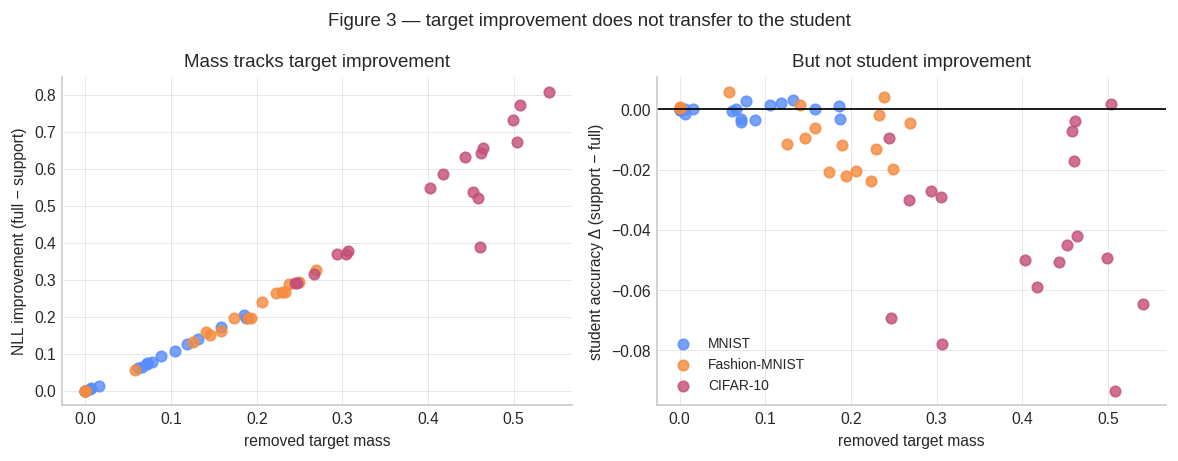

,mass–target gain r,mass–student Δ r
dataset,,
cifar,0.910,-0.042
fmnist,0.994,-0.506
mnist,0.999,0.075


**Interpretation.** Removed mass almost deterministically explains the target NLL change, as expected from the transformation. It does not consistently predict a student gain; on CIFAR-10 the association is essentially absent. Correlation is not treated as causal evidence.

In [7]:
link = pd.DataFrame({
    'removed_mass': mechanism.set_index(INDEX).mass_removed,
    'target_nll_gain': -target_delta['Δ target NLL'],
    'student_accuracy_delta': support_student_delta,
}).dropna()
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7))
for dataset in DATASETS:
    block = link.xs(dataset, level='dataset')
    axes[0].scatter(block.removed_mass, block.target_nll_gain, label=DATASET_LABEL[dataset], alpha=.8)
    axes[1].scatter(block.removed_mass, block.student_accuracy_delta, label=DATASET_LABEL[dataset], alpha=.8)
axes[0].set(xlabel='removed target mass', ylabel='NLL improvement (full − support)',
            title='Mass tracks target improvement')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set(xlabel='removed target mass', ylabel='student accuracy Δ (support − full)',
            title='But not student improvement')
axes[1].legend(fontsize=8)
fig.suptitle('Figure 3 — target improvement does not transfer to the student')
fig.tight_layout(); save_figure(fig, 'fig3_mechanism_to_student'); plt.show()
corr = link.groupby(level='dataset').apply(
    lambda x: pd.Series({'mass–target gain r': x.removed_mass.corr(x.target_nll_gain),
                         'mass–student Δ r': x.removed_mass.corr(x.student_accuracy_delta)}),
    include_groups=False)
display(save_table(corr, 'table_mechanism_correlations').round(3))
display(Markdown('**Interpretation.** Removed mass almost deterministically explains the target NLL change, as expected from the transformation. It does not consistently predict a student gain; on CIFAR-10 the association is essentially absent. Correlation is not treated as causal evidence.'))

## 8–9. ORACLE — soft correct-teacher knowledge versus the hard label

ORACLE-full averages full distributions only from teachers whose argmax is the true proxy label. ORACLE-class-only emits the true one-hot label when at least one teacher is correct and falls back to FedDF otherwise. This is a dark-knowledge control, not the expertise-support intervention. The matched supervised arm uses the same samples, initialization, order, updates, KL loss and temperature.

,no_correct_rate,max_no_correct_rate,onehot_violations,Δ student class-only − full,Δ student class-only − supervised
dataset,,,,,
cifar,0.0314,0.0717,0.0,0.0292,0.0353
fmnist,0.0094,0.0337,0.0,0.0063,-0.0001
mnist,0.0015,0.0033,0.0,-0.0007,-0.0016


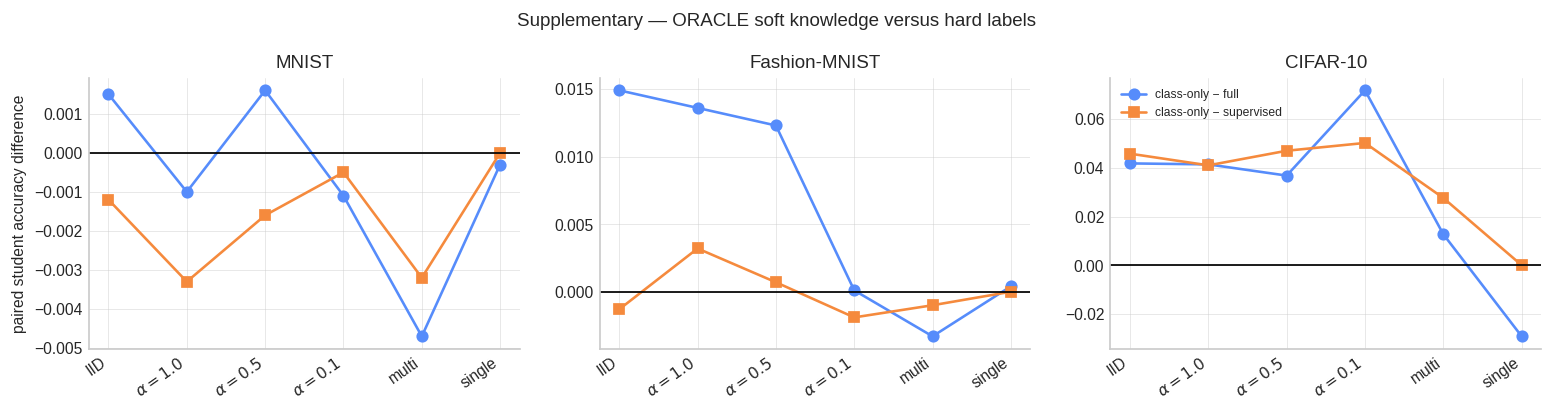

**Semantic verification.** Non-one-hot rows equal no-correct fallbacks in all 126 sanity runs: **True**. With zero fallback, ORACLE-class-only and supervised matched produce identical final students: **True**. The remaining CIFAR-10 difference is explained by the fallback frequency, not hidden optimization differences. ORACLE-class-only is on average better than ORACLE-full, so these data do not support a benefit from the dark knowledge of correct teachers.

In [8]:
oracle_target = canonical(targets.query("seed == 42 and proxy_size == 10000 and method in ['oracle_full','oracle_v2']"))
oracle_student = canonical(students.query("seed == 42 and proxy_size == 10000 and method in ['oracle_full','oracle_v2','supervised_matched']"))
oracle_pivot = oracle_student.pivot(index=['dataset', 'regime'], columns='method', values='student_test_accuracy')
oracle_summary = oracle_target.query("method == 'oracle_v2'").groupby('dataset').agg(
    no_correct_rate=('oracle_no_correct_rate', 'mean'),
    max_no_correct_rate=('oracle_no_correct_rate', 'max'),
    onehot_violations=('non_one_hot_rows_when_oracle_available', 'sum'))
oracle_summary['Δ student class-only − full'] = (oracle_pivot.oracle_v2 - oracle_pivot.oracle_full).groupby(level='dataset').mean()
oracle_summary['Δ student class-only − supervised'] = (oracle_pivot.oracle_v2 - oracle_pivot.supervised_matched).groupby(level='dataset').mean()
display(save_table(oracle_summary, 'table_oracle_control').round(4))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.3), sharey=False)
for ax, dataset in zip(axes, DATASETS):
    block = oracle_pivot.xs(dataset, level='dataset').reindex(REGIMES)
    ax.plot(range(len(REGIMES)), block.oracle_v2 - block.oracle_full, marker='o', label='class-only − full')
    ax.plot(range(len(REGIMES)), block.oracle_v2 - block.supervised_matched, marker='s', label='class-only − supervised')
    ax.axhline(0, color='black', linewidth=1); ax.set_title(DATASET_LABEL[dataset])
    ax.set_xticks(range(len(REGIMES))); ax.set_xticklabels([REGIME_LABEL[x] for x in REGIMES], rotation=35, ha='right')
axes[0].set_ylabel('paired student accuracy difference')
axes[-1].legend(fontsize=7)
fig.suptitle('Supplementary — ORACLE soft knowledge versus hard labels')
fig.tight_layout(); save_figure(fig, 'supp_oracle_control'); plt.show()

exact_rows = bool((oracle_sanity.target_rows_different == oracle_sanity.oracle_no_correct_count).all())
exact_students = bool(oracle_sanity.query('oracle_no_correct_count == 0').identical_final_student.all())
display(Markdown(f'**Semantic verification.** Non-one-hot rows equal no-correct fallbacks in all 126 sanity runs: **{exact_rows}**. With zero fallback, ORACLE-class-only and supervised matched produce identical final students: **{exact_students}**. The remaining CIFAR-10 difference is explained by the fallback frequency, not hidden optimization differences. ORACLE-class-only is on average better than ORACLE-full, so these data do not support a benefit from the dark knowledge of correct teachers.'))

## 10. How much labeled proxy data is enough for supervised learning?

Supervised targets and final model hashes are identical across heterogeneity regimes for a fixed dataset, size and recipe. They are therefore deduplicated before analysis; regimes are not treated as independent supervised repetitions. The curve experiment has seed 42 only.

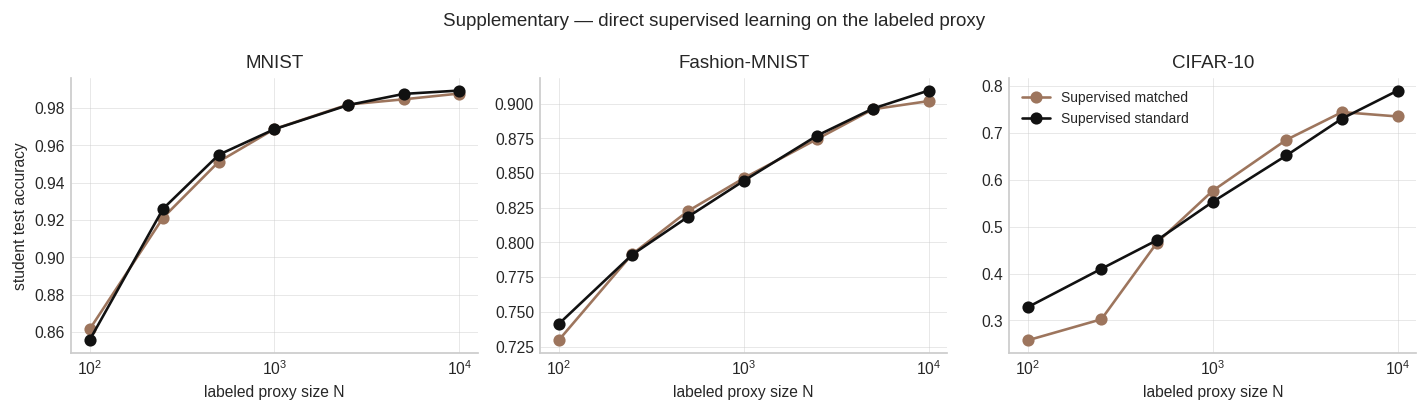

accuracy at N=100  accuracy at N=10000  \
dataset method                                                        
cifar   Supervised matched              0.2577               0.7347   
        Supervised standard             0.3283               0.7900   
fmnist  Supervised matched              0.7295               0.9018   
        Supervised standard             0.7412               0.9094   
mnist   Supervised matched              0.8613               0.9877   
        Supervised standard             0.8555               0.9893   

                             first N within 1pp of own N=10000  \
dataset method                                                   
cifar   Supervised matched                                5000   
        Supervised standard                              10000   
fmnist  Supervised matched                                5000   
        Supervised standard                              10000   
mnist   Supervised matched                                2500   
        Supervised standard                               2500   

                             first N within 2pp of own N=10000  
dataset method                                                  
cifar   Supervised matched                                5000  
        Supervised standard                              10000  
fmnist  Supervised matched                                5000  
        Supervised standard                               5000  
mnist   Supervised matched                                1000  
        Supervised standard                               2500

**Result.** MNIST saturates quickly; Fashion-MNIST needs several thousand labels; CIFAR-10 continues improving through the full 10k proxy under the standard recipe. The non-monotonic final point of the matched CIFAR curve is reported rather than smoothed away.

In [9]:
curve = canonical(students.query('seed == 42 and method in @CURVE'))
supervised = (curve.query("method in ['supervised_matched','supervised_standard']")
              .sort_values(['dataset','proxy_size','method','regime']))
assert supervised.groupby(['dataset','proxy_size','method']).student_final_sha256.nunique().max() == 1
supervised = supervised.drop_duplicates(['dataset','proxy_size','method'])
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.3), sharey=False)
for ax, dataset in zip(axes, DATASETS):
    block = supervised.query('dataset == @dataset')
    for method in ['supervised_matched','supervised_standard']:
        line = block.query('method == @method').sort_values('proxy_size')
        ax.plot(line.proxy_size, line.student_test_accuracy, marker='o', label=LABEL[method], color=COLOR[method])
    ax.set_xscale('log'); ax.set_title(DATASET_LABEL[dataset]); ax.set_xlabel('labeled proxy size N')
axes[0].set_ylabel('student test accuracy'); axes[-1].legend(fontsize=8)
fig.suptitle('Supplementary — direct supervised learning on the labeled proxy')
fig.tight_layout(); save_figure(fig, 'supp_supervised_proxy_curve'); plt.show()

saturation = []
for (dataset, method), block in supervised.groupby(['dataset','method']):
    block = block.sort_values('proxy_size'); full = block.query('proxy_size == 10000').student_test_accuracy.iloc[0]
    row = {'dataset': dataset, 'method': LABEL[method], 'accuracy at N=100': block.query('proxy_size == 100').student_test_accuracy.iloc[0],
           'accuracy at N=10000': full}
    for tolerance in [.01, .02]:
        reached = block[block.student_test_accuracy >= full - tolerance]
        row[f'first N within {int(tolerance*100)}pp of own N=10000'] = int(reached.proxy_size.iloc[0]) if len(reached) else 'not reached'
    saturation.append(row)
saturation = pd.DataFrame(saturation).set_index(['dataset','method'])
display(save_table(saturation, 'table_supervised_saturation').round(4))
display(Markdown('**Result.** MNIST saturates quickly; Fashion-MNIST needs several thousand labels; CIFAR-10 continues improving through the full 10k proxy under the standard recipe. The non-monotonic final point of the matched CIFAR curve is reported rather than smoothed away.'))

## 11–12. Proxy sample efficiency of KD and measured cross-overs

Here $|P|$ is total fully labeled proxy size, not a label-budget experiment. Curves exist for seed 42. To keep the main figure readable, KD lines summarize the six regimes descriptively with their min–max range; the supervised line is the single deduplicated result. The range is heterogeneity variation, not a confidence interval.

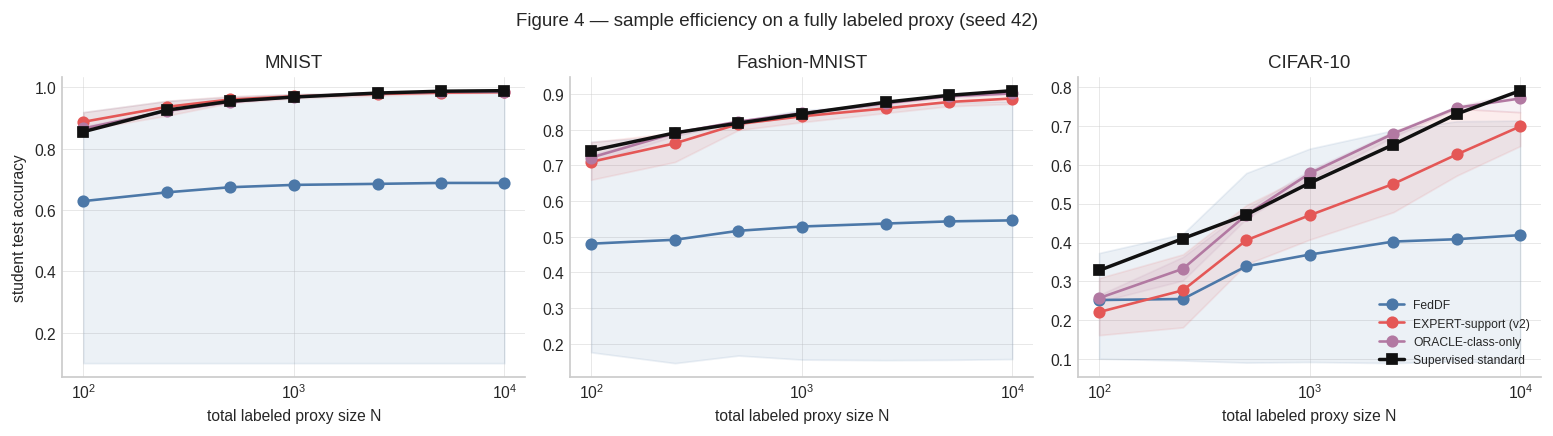

EXPERT-support − supervised                           \
                                          mean    min    max <lambda_0>   
dataset proxy_size                                                        
cifar   100                             -0.107 -0.166 -0.020          0   
        500                             -0.065 -0.127  0.024          1   
        10000                           -0.092 -0.142 -0.055          0   
fmnist  100                             -0.031 -0.082  0.024          1   
        500                             -0.002 -0.019  0.004          4   
        10000                           -0.022 -0.037 -0.002          0   
mnist   100                              0.032  0.006  0.064          6   
        500                              0.006 -0.005  0.017          3   
        10000                           -0.005 -0.006 -0.002          0   

                   FedDF − supervised                           
                                 mean    min    max <lambda_0>  
dataset proxy_size                                              
cifar   100                    -0.076 -0.227  0.045          3  
        500                    -0.132 -0.380  0.107          2  
        10000                  -0.371 -0.700 -0.077          0  
fmnist  100                    -0.261 -0.565  0.025          2  
        500                    -0.302 -0.652  0.006          2  
        10000                  -0.364 -0.752 -0.030          0  
mnist   100                    -0.226 -0.755  0.064          3  
        500                    -0.280 -0.854  0.015          2  
        10000                  -0.301 -0.888 -0.006          0

EXPERT-support reference at N=10000  \
dataset regime   method                                                     
cifar   alpha0p1 Supervised standard                               0.7166   
                 FedDF                                             0.7166   
        alpha0p5 Supervised standard                               0.6907   
                 FedDF                                             0.6907   
        alpha1p0 Supervised standard                               0.6476   
                 FedDF                                             0.6476   
        iid      Supervised standard                               0.6926   
                 FedDF                                             0.6926   
        multi    Supervised standard                               0.7070   
                 FedDF                                             0.7070   
        single   Supervised standard                               0.7347   
                 FedDF                                             0.7347   
fmnist  alpha0p1 Supervised standard                               0.8763   
                 FedDF                                             0.8763   
        alpha0p5 Supervised standard                               0.8772   
                 FedDF                                             0.8772   
        alpha1p0 Supervised standard                               0.8899   
                 FedDF                                             0.8899   
        iid      Supervised standard                               0.8723   
                 FedDF                                             0.8723   
        multi    Supervised standard                               0.9070   
                 FedDF                                             0.9070   
        single   Supervised standard                               0.9018   
                 FedDF                                             0.9018   
mnist   alpha0p1 Supervised standard                               0.9828   
                 FedDF                                             0.9828   
        alpha0p5 Supervised standard                               0.9833   
                 FedDF                                             0.9833   
        alpha1p0 Supervised standard                               0.9854   
                 FedDF                                             0.9854   
        iid      Supervised standard                               0.9836   
                 FedDF                                             0.9836   
        multi    Supervised standard                               0.9845   
                 FedDF                                             0.9845   
        single   Supervised standard                               0.9877   
                 FedDF                                             0.9877   

                                     first N within 1pp first N within 2pp  
dataset regime   method                                                     
cifar   alpha0p1 Supervised standard               5000               5000  
                 FedDF                      not reached        not reached  
        alpha0p5 Supervised standard               5000               5000  
                 FedDF                      not reached        not reached  
        alpha1p0 Supervised standard               2500               2500  
                 FedDF                             2500               2500  
        iid      Supervised standard               5000               5000  
                 FedDF                             2500               2500  
        multi    Supervised standard               5000               5000  
                 FedDF                      not reached        not reached  
        single   Supervised standard               5000               5000  
                 FedDF                      not reached        not reached  
fmnist  alpha0p1 Supervised stand

**Result.** EXPERT-support is not generally more sample-efficient than direct supervision: standard supervised is already better in every CIFAR-10 regime at N=100 and in most Fashion-MNIST cells. A real low-N KD advantage appears consistently only on MNIST. FedDF rarely catches EXPERT-support and often never reaches its N=10k reference within the tested range. Supervised catches or exceeds that reference much earlier, especially on MNIST.

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.5), sharey=False)
for ax, dataset in zip(axes, DATASETS):
    block = curve.query('dataset == @dataset')
    for method in ['feddf','expert_v2','oracle_v2']:
        stats = block.query('method == @method').groupby('proxy_size').student_test_accuracy.agg(['mean','min','max']).reindex(SIZES)
        ax.plot(stats.index, stats['mean'], marker='o', color=COLOR[method], label=LABEL[method])
        ax.fill_between(stats.index, stats['min'], stats['max'], color=COLOR[method], alpha=.10)
    sup = supervised.query("dataset == @dataset and method == 'supervised_standard'").sort_values('proxy_size')
    ax.plot(sup.proxy_size, sup.student_test_accuracy, marker='s', color=COLOR['supervised_standard'],
            linewidth=2, label=LABEL['supervised_standard'])
    ax.set_xscale('log'); ax.set_title(DATASET_LABEL[dataset]); ax.set_xlabel('total labeled proxy size N')
axes[0].set_ylabel('student test accuracy')
axes[-1].legend(fontsize=7, loc='lower right')
fig.suptitle('Figure 4 — sample efficiency on a fully labeled proxy (seed 42)')
fig.tight_layout(); save_figure(fig, 'fig4_proxy_sample_efficiency'); plt.show()

curve_pivot = curve.pivot(index=['dataset','regime','proxy_size'], columns='method', values='student_test_accuracy')
kd_advantage = pd.DataFrame({'EXPERT-support − supervised': curve_pivot.expert_v2 - curve_pivot.supervised_standard,
                             'FedDF − supervised': curve_pivot.feddf - curve_pivot.supervised_standard})
advantage_summary = kd_advantage.groupby(['dataset','proxy_size']).agg(['mean','min','max', lambda x: int((x>0).sum())])
save_table(advantage_summary, 'table_kd_minus_supervised')
display(advantage_summary.loc[pd.IndexSlice[:, [100,500,10000]], :].round(3))

crossings = []
for (dataset, regime), block in curve_pivot.groupby(level=['dataset','regime']):
    block = block.droplevel(['dataset','regime']).sort_index()
    reference = block.loc[10000, 'expert_v2']
    for method in ['supervised_standard','feddf']:
        row = {'dataset': dataset, 'regime': regime, 'method': LABEL[method],
               'EXPERT-support reference at N=10000': reference}
        for tolerance in [.01,.02]:
            reached = block[block[method] >= reference - tolerance]
            row[f'first N within {int(tolerance*100)}pp'] = int(reached.index[0]) if len(reached) else 'not reached'
        crossings.append(row)
crossings = pd.DataFrame(crossings).set_index(['dataset','regime','method'])
display(save_table(crossings, 'table_proxy_crossings'))
display(Markdown('**Result.** EXPERT-support is not generally more sample-efficient than direct supervision: standard supervised is already better in every CIFAR-10 regime at N=100 and in most Fashion-MNIST cells. A real low-N KD advantage appears consistently only on MNIST. FedDF rarely catches EXPERT-support and often never reaches its N=10k reference within the tested range. Supervised catches or exceeds that reference much earlier, especially on MNIST.'))

## 13–14. Robustness of the expertise definition

Thresholds are the dataset-specific canonical value plus $-0.05,0,+0.05$. This is a robustness check, not test-set tuning. Local test is then used only to audit whether holdout-defined expert entries remain competent.

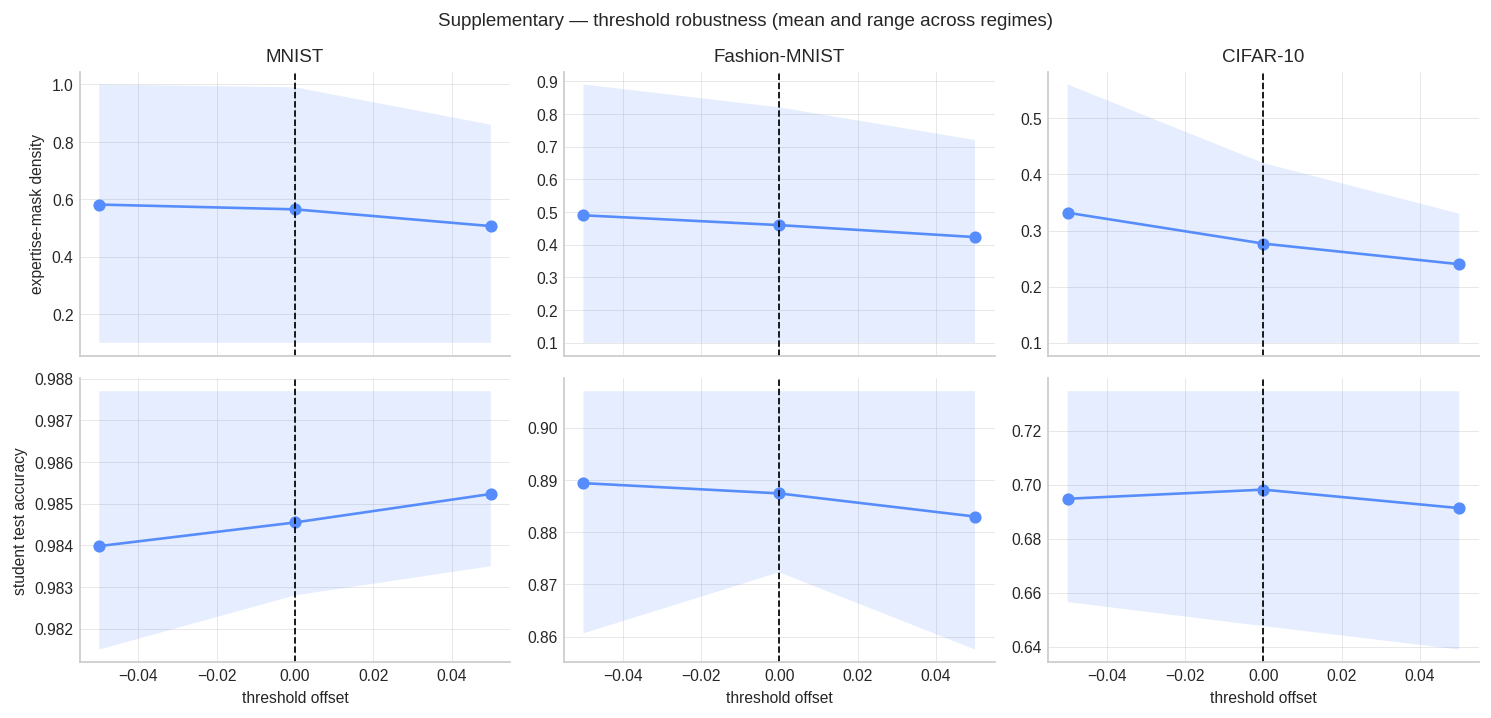

mask_density  mean_support_classes  min_class_coverage  \
dataset offset                                                           
cifar   -0.05          0.332                 3.317               1.000   
         0.00          0.277                 2.767               0.833   
         0.05          0.240                 2.400               0.833   
fmnist  -0.05          0.490                 4.900               2.000   
         0.00          0.460                 4.600               1.667   
         0.05          0.423                 4.233               1.167   
mnist   -0.05          0.582                 5.817               4.333   
         0.00          0.565                 5.650               4.000   
         0.05          0.507                 5.067               3.167   

                mean_selected_teachers  fallback_rate  mass_removed  \
dataset offset                                                        
cifar   -0.05                    3.327          0.033         0.379   
         0.00                    2.774          0.066         0.421   
         0.05                    2.402          0.066         0.443   
fmnist  -0.05                    4.900          0.000         0.133   
         0.00                    4.600          0.017         0.151   
         0.05                    4.233          0.017         0.172   
mnist   -0.05                    5.817          0.000         0.068   
         0.00                    5.650          0.000         0.079   
         0.05                    5.067          0.000         0.111   

                target_nll  student_test_accuracy  
dataset offset                                     
cifar   -0.05        0.656                  0.695  
         0.00        0.578                  0.698  
         0.05        0.534                  0.691  
fmnist  -0.05        0.561                  0.889  
         0.00        0.524                  0.887  
         0.05        0.493                  0.883  
mnist   -0.05        0.520                  0.984  
         0.00        0.504                  0.985  
         0.05        0.452                  0.985

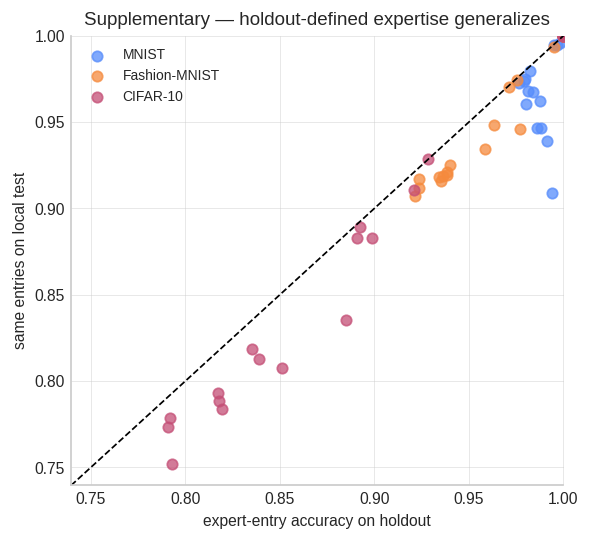

,expert_holdout_accuracy,expert_local_test_accuracy,expert_holdout_to_test_gap,expert_local_test_pass_rate,holdout_test_class_accuracy_correlation
dataset,,,,,
cifar,0.876,0.858,-0.019,0.900,0.923
fmnist,0.957,0.946,-0.012,0.948,0.873
mnist,0.989,0.971,-0.017,0.952,0.438


**Result.** Masks become smaller and targets sharper as the threshold rises, but student accuracy is comparatively stable around the canonical choice: the worst cell range is 3.7 pp, with much smaller variation on MNIST. Holdout-to-test transfer is strong on CIFAR-10/Fashion-MNIST; MNIST correlations are weakened by ceiling effects although expert-entry accuracy remains high.

In [11]:
threshold = students.query("seed == 42 and proxy_size == 10000 and method == 'expert_v2'").copy()
threshold['offset'] = threshold.apply(lambda row: round(row.threshold - CANONICAL[row.dataset], 2), axis=1)
threshold['mean_support_classes'] = threshold.mask_support_per_teacher.map(np.mean)
threshold['min_class_coverage'] = threshold.mask_coverage_per_class.map(np.min)
fig, axes = plt.subplots(2, 3, figsize=(12, 5.8), sharex='col')
for col, dataset in enumerate(DATASETS):
    block = threshold.query('dataset == @dataset')
    for row, metric in enumerate(['mask_density','student_test_accuracy']):
        stats = block.groupby('offset')[metric].agg(['mean','min','max']).sort_index()
        axes[row,col].plot(stats.index, stats['mean'], marker='o')
        axes[row,col].fill_between(stats.index, stats['min'], stats['max'], alpha=.15)
        axes[row,col].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[0,col].set_title(DATASET_LABEL[dataset]); axes[1,col].set_xlabel('threshold offset')
axes[0,0].set_ylabel('expertise-mask density'); axes[1,0].set_ylabel('student test accuracy')
fig.suptitle('Supplementary — threshold robustness (mean and range across regimes)')
fig.tight_layout(); save_figure(fig, 'supp_threshold_robustness'); plt.show()
threshold_summary = threshold.groupby(['dataset','offset'])[[
    'mask_density','mean_support_classes','min_class_coverage','mean_selected_teachers',
    'fallback_rate','mass_removed','target_nll','student_test_accuracy']].mean()
display(save_table(threshold_summary, 'table_threshold_robustness').round(3))

generalization = mechanism.dropna(subset=['expert_holdout_accuracy','expert_local_test_accuracy'])
fig, ax = plt.subplots(figsize=(4.8,4.4))
for dataset in DATASETS:
    b = generalization.query('dataset == @dataset')
    ax.scatter(b.expert_holdout_accuracy, b.expert_local_test_accuracy, label=DATASET_LABEL[dataset], alpha=.75)
lo = min(ax.get_xlim()[0], ax.get_ylim()[0]); ax.plot([lo,1],[lo,1],'--',color='black',linewidth=1)
ax.set(xlim=(lo,1), ylim=(lo,1), xlabel='expert-entry accuracy on holdout',
       ylabel='same entries on local test', title='Supplementary — holdout-defined expertise generalizes')
ax.legend(fontsize=8); fig.tight_layout(); save_figure(fig, 'supp_holdout_test_generalization'); plt.show()
generalization_summary = generalization.groupby('dataset')[[
    'expert_holdout_accuracy','expert_local_test_accuracy','expert_holdout_to_test_gap',
    'expert_local_test_pass_rate','holdout_test_class_accuracy_correlation']].mean()
display(save_table(generalization_summary, 'table_holdout_test_generalization').round(3))
display(Markdown('**Result.** Masks become smaller and targets sharper as the threshold rises, but student accuracy is comparatively stable around the canonical choice: the worst cell range is 3.7 pp, with much smaller variation on MNIST. Holdout-to-test transfer is strong on CIFAR-10/Fashion-MNIST; MNIST correlations are weakened by ceiling effects although expert-entry accuracy remains high.'))

## 15–17. Seed robustness, dataset dependence, and the `single` limiting case

Seeds—not clients—are the independent repetitions. With only three seeds, the analysis emphasizes paired effect sizes and sign consistency. `single` is reported separately because each teacher has exactly one supported class, making EXPERT-support a hard class target whenever routed.

In [12]:
paired_by_cell = pd.DataFrame({'v2 − full': student_pivot.expert_v2-student_pivot.expert_full,
                               'v2 − FedDF': student_pivot.expert_v2-student_pivot.feddf})
seed_effect = paired_by_cell.groupby(['dataset','regime']).agg(['mean','std',lambda x:list(np.round(x,4))])
display(save_table(seed_effect, 'table_multiseed_effects'))

single = mechanism.query("regime == 'single'").copy()
single['mean_support_classes'] = single.mask_support_per_teacher.map(np.mean)
single_table = single.groupby('dataset')[[
    'mask_density','mean_support_classes','mean_selected_teachers','fallback_rate',
    'mass_removed','target_entropy']].mean()
single_table['student Δ v2 − full'] = (student_pivot.expert_v2-student_pivot.expert_full).xs('single',level='regime').groupby(level='dataset').mean()
display(save_table(single_table, 'table_single_limiting_case').round(4))
display(Markdown('**Synthesis.** The student penalty is concentrated on CIFAR-10, is smaller on Fashion-MNIST and nearly zero at the MNIST ceiling. It is not monotonic with the proposed heterogeneity ordering. In `single`, support size is exactly one and target entropy is essentially zero; this is a useful stress test and a degenerate hard-target limit, not a representative summary of support-aware KD.'))

v2 − full                                        v2 − FedDF  \
                      mean       std                   <lambda_0>       mean   
dataset regime                                                                 
cifar   alpha0p1 -0.034767  0.026906    [-0.0037, -0.0506, -0.05]   0.335733   
        alpha0p5 -0.029800  0.027602    [-0.0492, 0.0018, -0.042]   0.132100   
        alpha1p0 -0.072300  0.018416  [-0.0933, -0.0589, -0.0647]  -0.030000   
        iid      -0.023033  0.019657    [-0.017, -0.045, -0.0071]  -0.034967   
        multi    -0.035267  0.030579  [-0.0271, -0.0096, -0.0691]   0.488333   
        single   -0.045633  0.027773    [-0.0292, -0.0777, -0.03]   0.644567   
fmnist  alpha0p1 -0.012333  0.010216   [-0.0222, -0.0018, -0.013]   0.375033   
        alpha0p5 -0.014900  0.009012  [-0.0045, -0.0204, -0.0198]   0.049500   
        alpha1p0 -0.013500  0.015407   [0.0042, -0.0208, -0.0239]   0.003200   
        iid      -0.009133  0.002768  [-0.0095, -0.0117, -0.0062]  -0.007200   
        multi    -0.001433  0.009063    [0.0058, -0.0116, 0.0015]   0.583700   
        single    0.000567  0.000289     [0.0004, 0.0009, 0.0004]   0.785533   
mnist   alpha0p1 -0.000600  0.002402    [0.0013, -0.0033, 0.0002]   0.292967   
        alpha0p5  0.002267  0.000751      [0.003, 0.0015, 0.0023]   0.020900   
        alpha1p0  0.000900  0.001778    [0.0029, 0.0003, -0.0005]   0.003000   
        iid      -0.000267  0.000981    [0.0003, -0.0014, 0.0003]   0.000067   
        multi    -0.003633  0.000551  [-0.0042, -0.0036, -0.0031]   0.721767   
        single   -0.000100  0.000346   [-0.0003, -0.0003, 0.0003]   0.887800   

                                                         
                       std                   <lambda_0>  
dataset regime                                           
cifar   alpha0p1  0.075857     [0.4227, 0.2832, 0.3013]  
        alpha0p5  0.026521     [0.1105, 0.1241, 0.1617]  
        alpha1p0  0.004258  [-0.0297, -0.0344, -0.0259]  
        iid       0.022592   [-0.0205, -0.061, -0.0234]  
        multi     0.113996     [0.5478, 0.3569, 0.5603]  
        single    0.002850     [0.6446, 0.6417, 0.6474]  
fmnist  alpha0p1  0.169399      [0.5263, 0.4068, 0.192]  
        alpha0p5  0.046893    [0.0925, -0.0005, 0.0565]  
        alpha1p0  0.012603    [0.0169, 0.0006, -0.0079]  
        iid       0.001552  [-0.0071, -0.0088, -0.0057]  
        multi     0.083206      [0.6759, 0.5142, 0.561]  
        single    0.035276     [0.7448, 0.8059, 0.8059]  
mnist   alpha0p1  0.196322     [0.0802, 0.4671, 0.3316]  
        alpha0p5  0.006080     [0.0266, 0.0216, 0.0145]  
        alpha1p0  0.001300     [0.0045, 0.0022, 0.0023]  
        iid       0.000950     [0.0001, -0.0009, 0.001]  
        multi     0.130622     [0.7783, 0.5724, 0.8146]  
        single    0.002835      [0.8868, 0.8856, 0.891]

,mask_density,mean_support_classes,mean_selected_teachers,fallback_rate,mass_removed,target_entropy,student Δ v2 − full
dataset,,,,,,,
cifar,0.1,1.0,1.0,0.0,0.2929,0.0,-0.0456
fmnist,0.1,1.0,1.0,0.0,0.0000,0.0,0.0006
mnist,0.1,1.0,1.0,0.0,0.0000,0.0,-0.0001


**Synthesis.** The student penalty is concentrated on CIFAR-10, is smaller on Fashion-MNIST and nearly zero at the MNIST ceiling. It is not monotonic with the proposed heterogeneity ordering. In `single`, support size is exactly one and target entropy is essentially zero; this is a useful stress test and a degenerate hard-target limit, not a representative summary of support-aware KD.

## 18. Minimal final method set

**Main paper:** FedDF, Support-only, EXPERT-full (v1), and EXPERT-support (v2) establish the factorial mechanism; supervised standard is essential in the proxy-efficiency figure.

**Supplementary/control:** ORACLE-full, ORACLE-class-only, supervised matched, threshold sensitivity, and holdout→test validation.

**Remove from the Article 1 narrative:** historical Study I methods not regenerated under `protocol_v1`, including Energy. They add no clean causal contrast and are unavailable in the authoritative corpus. The paper should not reproduce a flat legacy benchmark.

## 19–20. Paper figures and tables

The figures below are recommended for the main paper and have been exported as both PNG and PDF. Detailed controls are exported with the `supp_` prefix. Tables are CSV files generated from the authoritative rows.

In [13]:
figure_registry = pd.DataFrame([
    ['Figure 1', 'fig1_out_of_expertise_mass', 'Mechanistic motivation: unwanted probability mass'],
    ['Figure 2', 'fig2_main_student_performance', 'Main factorial student result'],
    ['Figure 3', 'fig3_mechanism_to_student', 'Target improvement versus student transfer'],
    ['Figure 4', 'fig4_proxy_sample_efficiency', 'KD versus supervised by proxy size'],
], columns=['Paper item','Export stem','Scientific message']).set_index('Paper item')
table_registry = pd.DataFrame([
    ['Setup', 'table_experimental_setup.csv'], ['Method information', 'table_method_information.csv'],
    ['Main paired effects', 'table_main_paired_effects.csv'], ['Target effects', 'table_target_full_to_support.csv'],
    ['Proxy cross-overs', 'table_proxy_crossings.csv'], ['Claims', 'table_claim_audit.csv'],
], columns=['Paper use','File']).set_index('Paper use')
display(figure_registry); display(table_registry)
print(f'Figures: {FIGURES}')
print(f'Tables:  {TABLES}')

,Export stem,Scientific message
Paper item,,
Figure 1,fig1_out_of_expertise_mass,Mechanistic motivation: unwanted probability mass
Figure 2,fig2_main_student_performance,Main factorial student result
Figure 3,fig3_mechanism_to_student,Target improvement versus student transfer
Figure 4,fig4_proxy_sample_efficiency,KD versus supervised by proxy size


,File
Paper use,
Setup,table_experimental_setup.csv
Method information,table_method_information.csv
Main paired effects,table_main_paired_effects.csv
Target effects,table_target_full_to_support.csv
Proxy cross-overs,table_proxy_crossings.csv
Claims,table_claim_audit.csv


Figures: /home/roi/PycharmProjects/KD_v5/OUTPUTS/experiments/article_1/paper_analysis/figures
Tables:  /home/roi/PycharmProjects/KD_v5/OUTPUTS/experiments/article_1/paper_analysis/tables


## 21. What the experiments allow us to claim

Claims are classified from computed effects. “Strongly supported” refers to consistency in this corpus, not universal statistical proof.

In [14]:
mass_mean = mechanism.mass_removed.mean()
selection_delta = (student_pivot.expert_full-student_pivot.feddf)
support_delta = (student_pivot.expert_v2-student_pivot.expert_full)
small_n = kd_advantage.xs(100, level='proxy_size')['EXPERT-support − supervised']
claim_rows = [
    [1, 'Selected teachers place non-trivial mass outside expertise',
     'strongly supported' if mass_mean > .05 else 'unsupported', 'Figure 1; mechanism table'],
    [2, 'The problem increases monotonically with specialization', 'contradicted', 'Figure 1; single-case table'],
    [3, 'Support restriction improves target quality',
     'strongly supported' if (target_delta['Δ target NLL']<0).all() else 'conditionally supported', 'Target-effect table; Figure 3'],
    [4, 'Support restriction improves the final student',
     'contradicted' if support_delta.mean()<0 else 'supported', 'Figure 2; paired-effect table'],
    [5, 'The student effect is largest under strong heterogeneity', 'unsupported', 'Multi-seed table; Figure 2'],
    [6, 'Selection and support provide complementary student gains',
     'contradicted', 'Selection is positive; support intervention is negative'],
    [7, 'Soft information from correct teachers improves over hard labels',
     'contradicted', 'ORACLE control table/figure'],
    [8, 'KD is more sample-efficient than supervised at small N',
     'requires qualification', f'At N=100 EXPERT-support wins {int((small_n>0).sum())}/{len(small_n)} cells, concentrated on MNIST'],
    [9, 'Supervised learning closes the gap as proxy size grows',
     'strongly supported', 'Figure 4; cross-over table'],
    [10, 'Conclusions are robust to ±0.05 threshold perturbations',
     'conditionally supported', 'Threshold table; worst cell range 3.7 pp'],
]
claims = pd.DataFrame(claim_rows, columns=['#','Potential claim','Classification','Evidence']).set_index('#')
display(save_table(claims, 'table_claim_audit'))

,Potential claim,Classification,Evidence
#,,,
1,Selected teachers place non-trivial mass outsi...,strongly supported,Figure 1; mechanism table
2,The problem increases monotonically with speci...,contradicted,Figure 1; single-case table
3,Support restriction improves target quality,strongly supported,Target-effect table; Figure 3
4,Support restriction improves the final student,contradicted,Figure 2; paired-effect table
5,The student effect is largest under strong het...,unsupported,Multi-seed table; Figure 2
6,Selection and support provide complementary st...,contradicted,Selection is positive; support intervention is...
7,Soft information from correct teachers improve...,contradicted,ORACLE control table/figure
8,KD is more sample-efficient than supervised at...,requires qualification,"At N=100 EXPERT-support wins 7/18 cells, conce..."
9,Supervised learning closes the gap as proxy si...,strongly supported,Figure 4; cross-over table


## 22. Threats to validity discovered from the corpus

- Three ten-class datasets, ten clients and only three seeds for the central comparison limit generalization and formal inference.
- Proxy-size, ORACLE and threshold studies use seed 42 only. Their regime variation is descriptive, not replication.
- The public proxy is in-domain, fully labeled and shared; this is favorable and deliberately narrower than Article 2.
- Expertise is assumed available to the server and binarized with dataset-specific thresholds.
- MNIST ceiling effects suppress correlations and observable student gains.
- `single` turns support masking into a one-class/hard-target limit and must not stand for typical non-IID behavior.
- Teacher calibration and alternative temperatures were not varied; removing mass also reduces entropy, so the intervention changes both support and softness.
- Only one teacher/student architecture per dataset and one proxy construction were studied.
- Historical Study I baselines were not retained in compatible form; the analysis intentionally uses only regenerated `protocol_v1` comparisons.

## 23. Final scientific synthesis

The strongest defensible Article 1 is not a success story for EXPERT-support. It is a mechanistic study separating **who contributes** from **what they contribute**. Standard FedDF ignores specialization; historical EXPERT routing strongly improves over FedDF in most cells. Selected teachers do assign substantial probability outside their measured expertise, especially on CIFAR-10, and support masking removes it exactly as intended.

That intervention improves every measured target NLL and true-class probability, but it generally reduces final student accuracy, with the clearest penalty on CIFAR-10. The likely boundary is loss of useful soft structure or over-sharpening rather than absence of the proposed noise. ORACLE independently reaches the same qualitative lesson: hard class-only targets are at least as good as soft correct-teacher targets here, while fallback explains their departure from matched supervision.

With a fully labeled proxy, direct supervised training is a strong baseline and often preferable. Expertise-aware KD shows a consistent low-data advantage only on MNIST; supervised learning catches up rapidly and dominates broadly on CIFAR-10/Fashion-MNIST. Therefore the practical value of teacher knowledge is conditional on dataset and proxy size, not automatic.

**Recommended Results structure:** (1) clean protocol and factorial methods; (2) existence of out-of-expertise mass; (3) target improvement but failed student transfer; (4) ORACLE hard-versus-soft control; (5) proxy sample efficiency; (6) threshold/holdout/multi-seed robustness and `single` as supplementary limits.

**Bridge to Article 2.** Article 1 assumes a fully labeled proxy and known server-side expertise. Article 2 asks whether comparable behavior can be recovered when only a small portion of the proxy is labeled.

## 24. Mechanistic follow-up — support removal versus sharpness

This pre-registered follow-up uses three paired EXPERT conditions: EXPERT-full, EXPERT-support, and EXPERT-full with true-class probability fixed to EXPERT-support and a per-example tail power chosen to match its entropy exactly. The latter retains the full target's non-true-class support and tail ordering, so FULL→matched estimates the coupled sharpness/label-fidelity path and matched→SUPPORT estimates support removal at those quantities held fixed. This is descriptive until replicated.

In [ ]:
mechanism_targets = canonical(targets.query("dataset == 'cifar' and seed == 43 and proxy_size == 10000 and method in @MECHANISM_CONTROL")).copy()
mechanism_students = canonical(students.query("dataset == 'cifar' and seed == 43 and proxy_size == 10000 and method in @MECHANISM_CONTROL")).copy()
followup_index = ['dataset', 'seed', 'regime']
if mechanism_targets.empty or mechanism_students.empty:
    display(Markdown('**Mechanistic follow-up:** targets and/or students are not yet present. Run the `mechanism` preset for CIFAR seed 43, then rerun this notebook.'))
else:
    target_control = mechanism_targets.pivot(index=followup_index, columns='method', values=['target_entropy', 'target_nll', 'target_brier', 'target_true_probability', 'target_nonzero_classes_mean'])
    student_control = mechanism_students.pivot(index=followup_index, columns='method', values='student_test_accuracy')
    paired_fields = ['student_init_sha256', 'train_order_sha256', 'total_updates', 'paired_run_id']
    pairing_ok = all(mechanism_students.groupby(followup_index)[paired_fields].nunique().eq(1).all().all() for _ in [0])
    entropy_error = (target_control['target_entropy'].expert_full_entropy_matched - target_control['target_entropy'].expert_v2)
    followup = pd.DataFrame({
        'H(full)': target_control['target_entropy'].expert_full,
        'H(support)': target_control['target_entropy'].expert_v2,
        'H(full, matched)': target_control['target_entropy'].expert_full_entropy_matched,
        'entropy-match error': entropy_error,
        'classes(full)': target_control['target_nonzero_classes_mean'].expert_full,
        'classes(support)': target_control['target_nonzero_classes_mean'].expert_v2,
        'classes(full, matched)': target_control['target_nonzero_classes_mean'].expert_full_entropy_matched,
        'NLL(full)': target_control['target_nll'].expert_full,
        'NLL(support)': target_control['target_nll'].expert_v2,
        'NLL(full, matched)': target_control['target_nll'].expert_full_entropy_matched,
        'p(true, support)': target_control['target_true_probability'].expert_v2,
        'p(true, matched)': target_control['target_true_probability'].expert_full_entropy_matched,
        'student(full)': student_control.expert_full,
        'student(full, matched)': student_control.expert_full_entropy_matched,
        'student(support)': student_control.expert_v2,
        'sharpness path: matched - full': student_control.expert_full_entropy_matched - student_control.expert_full,
        'support path at equal entropy: support - matched': student_control.expert_v2 - student_control.expert_full_entropy_matched,
        'total: support - full': student_control.expert_v2 - student_control.expert_full,
    })
    display(save_table(followup, 'table_mechanism_entropy_control').round(4))
    assert pairing_ok, 'mechanistic-control students are not CRN paired'
    assert entropy_error.abs().max() < 1e-6, 'entropy control did not match EXPERT-support'
    true_probability_error = (target_control['target_true_probability'].expert_full_entropy_matched - target_control['target_true_probability'].expert_v2).abs().max()
    assert true_probability_error < 1e-6, 'label-fidelity control did not match EXPERT-support'
    display(Markdown(f'**Control checks.** Max entropy error = **{entropy_error.abs().max():.2e}**; max true-probability error = **{true_probability_error:.2e}**; CRN pairing = **{pairing_ok}**. The first student contrast estimates the coupled sharpness/label-fidelity path, while the second estimates support removal with both held fixed. It cannot establish generality beyond these single-seed CIFAR-10 cells.'))
